<a href="https://colab.research.google.com/github/ArhamUsman/AI-LAB/blob/main/k241016_Assignment_10%2C_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit_learn
!pip install imblearn

In [ ]:
import os
from google.colab import userdata
import kagglehub

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# Task 1 Dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Task 2 Dataset
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print("Path to competition files:", path)

#Task 3 Dataset
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


100%|██████████| 199k/199k [00:00<00:00, 34.6MB/s]

Extracting files...
Path to competition files: /root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques


100%|██████████| 62.0k/62.0k [00:00<00:00, 25.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1


**SUPERVISED LEARNING TASKS**
-
Task 1:
-
Credit Card Fraud Detection (Classification)

Dataset: Credit Card Fraud Detection (Kaggle)

Steps:
1. Load dataset
2. Handle class imbalance (undersampling/oversampling)
3. Apply feature scaling
4. Split data (70/30)

Models:
- Logistic Regression
- Random Forest

Evaluation:
- Accuracy
- Precision
- Recall
- F1-score

Deliverables:
- Model comparison
- Identify best model for imbalanced data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
import time

# 1. Load dataset
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

# 2. Apply feature scaling
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df = df.drop(['Time'], axis=1)

# 3. Handle class imbalance
X = df.drop('Class', axis=1)
y = df['Class']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Original shape: {y.value_counts()}")
print(f"Resampled shape: {y_res.value_counts()}")

# 4. Split data (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Replace your model initialization with this:
lr_model = LogisticRegression(max_iter=3000, n_jobs=-1)

# n_jobs=-1 uses all CPU cores
# max_samples=0.1 trains each tree on only 10% of the data (much faster!)
rf_model = RandomForestClassifier(
    n_estimators=15,
    max_depth=50,
    n_jobs=-1,
    max_samples=0.05,
    random_state=42
)

models = {"Logistic Regression": lr_model, "Random Forest": rf_model}
scores = []
print('')
for name, model in models.items():
    print(f"Now training: {name}...")
    s = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    e = time.time()
    print(f"\n--- {name} : Trained in {round(e-s,2)}s ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    scores.append(accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


print("Best model for imbalance data:", end='')
if (scores[0]>scores[1]):
  print(" Logistic Regression")
else:
  print(" Random Forest")

Original shape: Class
0    284315
1       492
Name: count, dtype: int64
Resampled shape: Class
0    284315
1    284315
Name: count, dtype: int64

Now training: Logistic Regression...

--- Logistic Regression : Trained in 3.62s ---
Accuracy: 0.9469
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     85149
           1       0.97      0.92      0.95     85440

    accuracy                           0.95    170589
   macro avg       0.95      0.95      0.95    170589
weighted avg       0.95      0.95      0.95    170589

Now training: Random Forest...

--- Random Forest : Trained in 2.71s ---
Accuracy: 0.9974
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85149
           1       1.00      1.00      1.00     85440

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

Best mod

Task 2:
-
House Price Prediction (Regression)

Dataset: House Prices – Advanced Regression Techniques (Kaggle)

Steps:
1. Handle missing values
2. Encode categorical variables
3. Apply feature scaling

Models:
- Linear Regression
- Decision Tree Regressor

Evaluation:
- MAE
- RMSE

Deliverables:
- Predicted vs Actual comparison
- Best model identification

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load dataset
# Adjust path to your specific environment
train_path = '/root/.cache/kagglehub/competitions/house-prices-advanced-regression-techniques/train.csv'
df = pd.read_csv(train_path)

# 2. Handle missing values (Preprocessing)
# Filling numerical missing values with median and categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 3. Encode categorical variables
# Converting text features to numerical features as required by Task 2 in Lab 10
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# 4. Feature Selection and Scaling
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Split data (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42)
}

error=[]
# 6. Train and Evaluate
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    print(f"\n--- {name} ---")
    print(f"Trained in: {training_time:.4f}s")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    error.append(rmse)
    # Show comparison for first 5 samples
    comparison = pd.DataFrame({'Actual': y_test[:5].values, 'Predicted': predictions[:5].astype(int)})
    print("Sample Comparison:\n", comparison)


print("\nBest Model:", end=' ')
if (error[0]>error[1]):
  print("Linear Regression")
else:
  print('Decision Tree Regressor')


--- Linear Regression ---
Trained in: 0.0753s
Mean Absolute Error (MAE): 22152.85
Root Mean Squared Error (RMSE): 33704.73
Sample Comparison:
    Actual  Predicted
0  154500     147122
1  325000     327004
2  115000     109611
3  159000     179284
4  315500     318821

--- Decision Tree Regressor ---
Trained in: 0.1014s
Mean Absolute Error (MAE): 27158.43
Root Mean Squared Error (RMSE): 41297.12
Sample Comparison:
    Actual  Predicted
0  154500     128000
1  325000     313000
2  115000     109900
3  159000     197500
4  315500     318000

Best Model: Decision Tree Regressor


**UNSUPERVISED LEARNING TASKS**
-
Task 3:
-
Customer Segmentation

Dataset: Customer Personality Analysis (Kaggle)

Steps:
1. Select relevant features
2. Handle missing values
3. Apply Standard Scaling

Apply:
- K-Means clustering
- Elbow Method (K = 2–10)

Deliverables:
- Elbow graph
- Cluster visualization
- Cluster labels

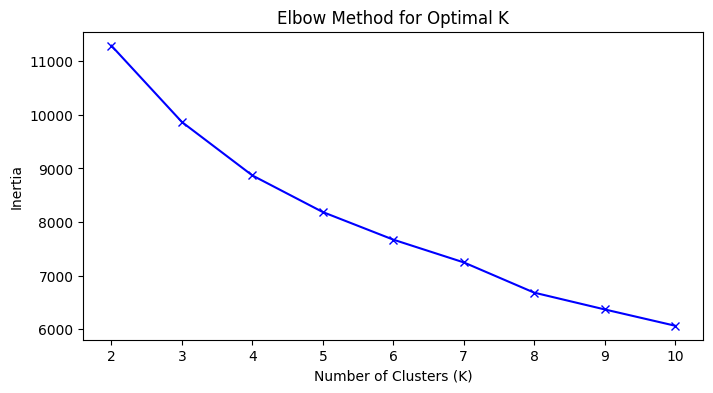

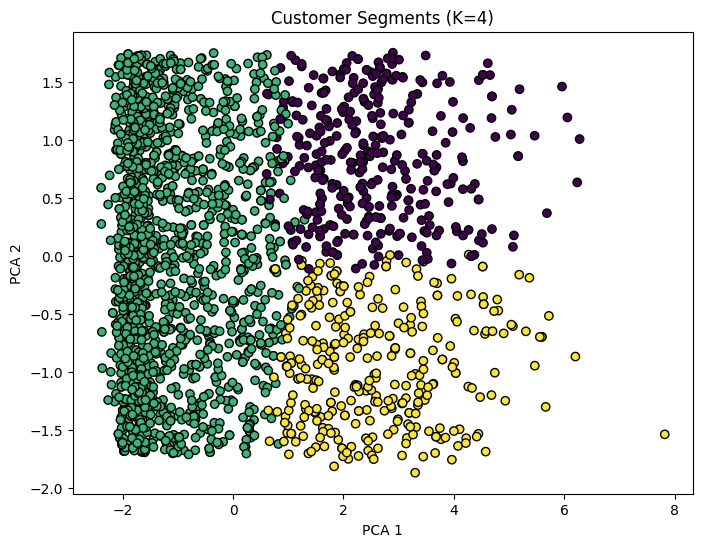


--- Cluster Labels Assigned ---
     ID  Cluster
0  5524        0
1  2174        2
2  4141        3
3  6182        2
4  5324        2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Dataset
path = '/root/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1/marketing_campaign.csv'
df = pd.read_csv(path, sep='\t')

# 2. Preprocessing
# Select relevant features for spending behavior
features = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_task = df[features].copy()

# Handle missing values (Income often has a few)
df_task['Income'] = df_task['Income'].fillna(df_task['Income'].median())

# 3. Standard Scaling (Crucial for K-Means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_task)

# 4. Elbow Method (Deliverable 1)
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# 5. Apply K-Means with Optimal K (e.g., K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_transform(scaled_data).argmax(axis=1) # Applying labels

# 6. Cluster Visualization using PCA (Deliverable 2)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster'], cmap='viridis', edgecolors='k')
plt.title(f'Customer Segments (K={optimal_k})')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

print("\n--- Cluster Labels Assigned ---")
print(df[['ID', 'Cluster']].head())